# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Yunas Wildan Yudhistira
- **Email:** yunaswildan467@gmail.com
- **ID Dicoding:** yunaswildan

## Menentukan Pertanyaan Bisnis
- Pertanyaan 1: Sejauh mana hubungan antara polutan gas terhadap konsentrasi PM2.5 pada Stasiun Aotizhongxin selama periode pengamatan tahun 2013 hingga 2017?"

- Pertanyaan 2: Apakah terdapat perbedaan signifikan pada tingkat polusi PM2.5 antara hari kerja dan akhir pekan sepanjang tahun 2013-2017?

- Pertanyaan 3: Bagaimana pengaruh tekanan udara terhadap akumulasi polutan PM10 berdasarkan data historis tahun 2013-2017?

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style untuk visualisasi
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv("PRSA_Data_Aotizhongxin_20130301-20170228.csv")

#### Menampilkan 5 Baris Pertama Dataset

In [3]:
# Memuat dataset
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


#### Rangkuman Insight Tahap Gathering Data

- Dataset yang digunakan berasal dari file resmi Air Quality Dataset dan terfokus pada stasiun `Aotizhongxin`.
- Struktur data bersifat time series per jam, sehingga analisis selanjutnya perlu mempertahankan urutan waktu dan konsistensi agregasi bulanan/musiman.
- Tahap gathering memastikan sumber data, lokasi file, dan konteks observasi sudah sesuai sebelum masuk ke pemeriksaan kualitas data.


### Assessing Data

#### Mengidentifikasi Masalah Data

Tahap ini bertujuan untuk mendeteksi permasalahan kualitas data sebelum dilakukan pembersihan. Masalah yang dicari meliputi missing values, duplikasi data, dan tipe data yang tidak sesuai.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


#### Menangani Masalah Data

Berdasarkan hasil identifikasi, berikut adalah tindakan yang akan dilakukan:
- **Missing Values**: Akan ditangani menggunakan metode Forward Fill (ffill) karena data bersifat time-series.
- **Duplikasi**: Tidak ditemukan duplikasi, sehingga tidak diperlukan tindakan penghapusan.
- **Tipe Data**: Kolom waktu (year, month, day, hour) akan digabung menjadi satu kolom datetime.

In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
CO,1776
O3,1719
NO2,1023
SO2,935
PM2.5,925
PM10,718
wd,81
RAIN,20
DEWP,20
PRES,20


In [6]:
print(f'Jumlah duplikasi penuh: {df.duplicated().sum()}')

Jumlah duplikasi penuh: 0


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,35064.0,NaN,NaN,NaN,17532.5,10122.249256,1.0,8766.75,17532.5,26298.25,35064.0
year,35064.0,NaN,NaN,NaN,2014.66256,1.177213,2013.0,2014.0,2015.0,2016.0,2017.0
month,35064.0,NaN,NaN,NaN,6.52293,3.448752,1.0,4.0,7.0,10.0,12.0
day,35064.0,NaN,NaN,NaN,15.729637,8.800218,1.0,8.0,16.0,23.0,31.0
hour,35064.0,NaN,NaN,NaN,11.5,6.922285,0.0,5.75,11.5,17.25,23.0
PM2.5,34139.0,NaN,NaN,NaN,82.773611,82.135694,3.0,22.0,58.0,114.0,898.0
PM10,34346.0,NaN,NaN,NaN,110.060391,95.223005,2.0,38.0,87.0,155.0,984.0
SO2,34129.0,NaN,NaN,NaN,17.375901,22.823017,0.2856,3.0,9.0,21.0,341.0
NO2,34041.0,NaN,NaN,NaN,59.305833,37.1162,2.0,30.0,53.0,82.0,290.0
CO,33288.0,NaN,NaN,NaN,1262.945145,1221.436236,100.0,500.0,900.0,1500.0,10000.0


#### Rangkuman Insight Tahap Assessing Data

- Dataset memiliki 35.064 baris dan 18 kolom, sehingga cukup memadai untuk analisis pola cuaca dan polusi dari 2013 sampai 2017.
- Ditemukan missing values pada beberapa kolom numerik seperti `CO`, `O3`, `NO2`, dan `PM2.5`, tetapi tidak ditemukan duplikasi penuh.
- Temuan ini menunjukkan bahwa masalah utama data ada pada nilai hilang, bukan duplikasi atau struktur file yang rusak.

### Cleaning Data

In [8]:
df.copy()
df.fillna(method='ffill', inplace=True)
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['day_type'] = df['datetime'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

print("Data Cleaning Selesai.")

Data Cleaning Selesai.


/tmp/ipykernel_9636/139851992.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [9]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


## Rangkuman Cleaning Data

- Metode Forward Fill (ffill) dipilih untuk menangani missing values karena data bersifat time-series (per jam). Hal ini menjaga kontinuitas data karena konsentrasi polutan cenderung stabil dan tidak berubah secara drastis dalam rentang waktu yang singkat.

- Transformasi tipe data datetime dilakukan dengan menggabungkan kolom waktu yang terpisah. Langkah ini sangat krusial agar data dapat diurutkan secara kronologis dan mempermudah proses resampling untuk analisis tren waktu.

- Pembuatan fitur day_type (Weekday vs Weekend) memberikan dimensi baru pada data, yang memungkinkan kita melakukan segmentasi polusi berdasarkan pola aktivitas mingguan masyarakat.

- Hasil Akhir Tahap Cleaning: Dataset kini telah bersih dari nilai kosong, memiliki struktur waktu yang valid, dan diperkaya dengan fitur kategori yang siap digunakan untuk menjawab pertanyaan bisnis.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   No        35064 non-null  int64         
 1   year      35064 non-null  int64         
 2   month     35064 non-null  int64         
 3   day       35064 non-null  int64         
 4   hour      35064 non-null  int64         
 5   PM2.5     35064 non-null  float64       
 6   PM10      35064 non-null  float64       
 7   SO2       35064 non-null  float64       
 8   NO2       35064 non-null  float64       
 9   CO        35064 non-null  float64       
 10  O3        35064 non-null  float64       
 11  TEMP      35064 non-null  float64       
 12  PRES      35064 non-null  float64       
 13  DEWP      35064 non-null  float64       
 14  RAIN      35064 non-null  float64       
 15  wd        35064 non-null  object        
 16  WSPM      35064 non-null  float64       
 17  station   35

In [11]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,day_type
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00,Weekday
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00,Weekday
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00,Weekday
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00,Weekday
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00,Weekday


In [12]:
df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES']].describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,83.163652,110.733262,17.573220,59.290826,1267.071954,55.184512,13.581908,1011.851716
std,82.290700,95.375762,22.819302,37.007696,1242.121599,57.582259,11.400761,10.404909
min,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000
25%,22.000000,38.000000,3.000000,30.000000,500.000000,7.000000,3.100000,1003.300000
50%,60.000000,88.000000,9.000000,54.000000,900.000000,41.000000,14.500000,1011.400000
75%,114.000000,157.000000,22.000000,81.000000,1600.000000,82.000000,23.300000,1020.100000
max,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000


### EDA Univariate

Analisis distribusi masing-masing variabel polutan secara individual untuk memahami sebaran dan karakteristik datanya.

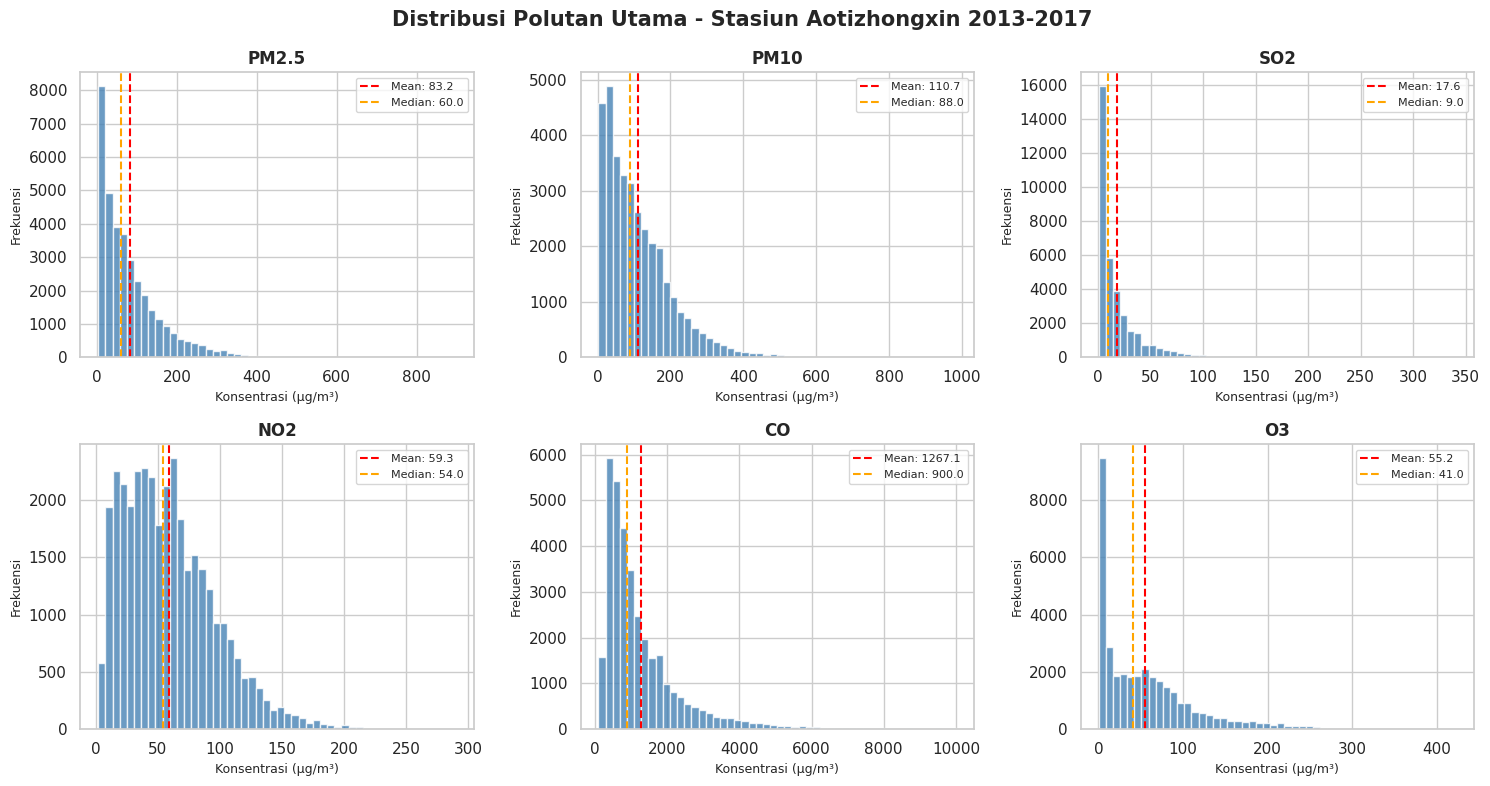

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribusi Polutan Utama - Stasiun Aotizhongxin 2013-2017", fontsize=15, fontweight='bold')

polutan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for i, col in enumerate(polutan):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Konsentrasi (µg/m³)', fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### EDA Multivariate

Analisis hubungan antar beberapa variabel secara bersamaan untuk menemukan pola dan korelasi yang lebih kompleks.

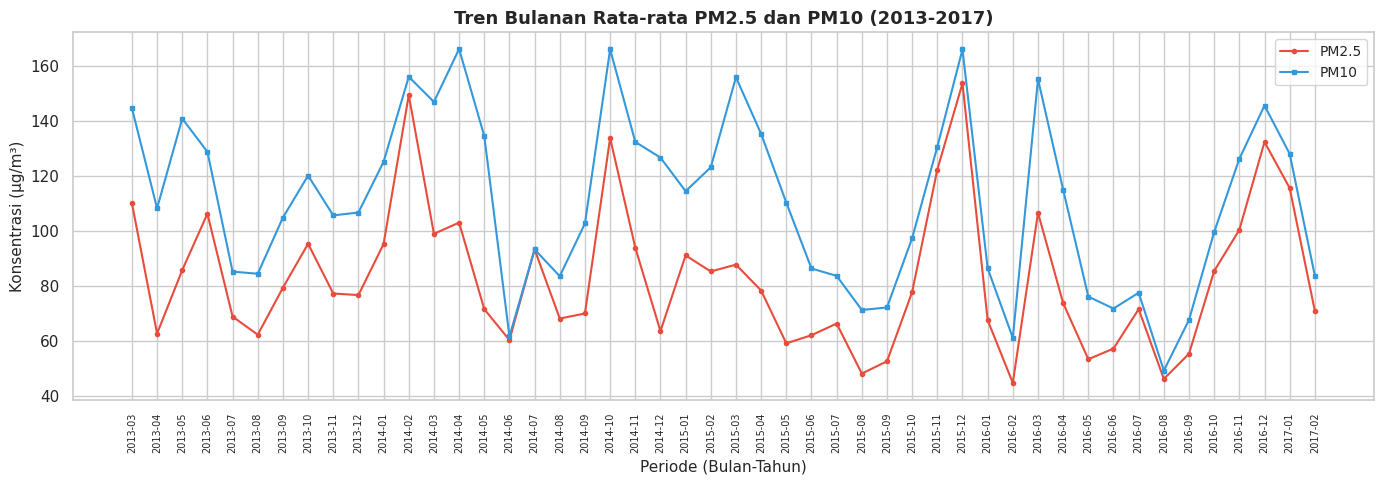

In [14]:
# EDA Multivariate: Tren Bulanan PM2.5 dan PM10
df['year_month'] = df['datetime'].dt.to_period('M')
monthly_trend = df.groupby('year_month')[['PM2.5', 'PM10']].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_trend.index.astype(str), monthly_trend['PM2.5'], marker='o', markersize=3,
        label='PM2.5', color='#E74C3C', linewidth=1.5)
ax.plot(monthly_trend.index.astype(str), monthly_trend['PM10'], marker='s', markersize=3,
        label='PM10', color='#3498DB', linewidth=1.5)
ax.set_title('Tren Bulanan Rata-rata PM2.5 dan PM10 (2013-2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Periode (Bulan-Tahun)', fontsize=11)
ax.set_ylabel('Konsentrasi (µg/m³)', fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

In [15]:
correlation_matrix = df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].corr()

In [16]:
weekday_weekend_analysis = df.groupby('day_type')['PM2.5'].mean().reset_index()

In [17]:
correlation_matrix

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.000000,0.872035,0.474893,0.675116,0.775057,-0.159296
PM10,0.872035,1.000000,0.470235,0.647966,0.677782,-0.146384
SO2,0.474893,0.470235,1.000000,0.429816,0.525074,-0.211762
NO2,0.675116,0.647966,0.429816,1.000000,0.680973,-0.497371
CO,0.775057,0.677782,0.525074,0.680973,1.000000,-0.324559
O3,-0.159296,-0.146384,-0.211762,-0.497371,-0.324559,1.000000


In [18]:
weekday_weekend_analysis

,day_type,PM2.5
0,Weekday,81.405026
1,Weekend,87.551804


## Rangkuman Insight Tahap EDA

- Karakteristik Data: Berdasarkan fungsi .info(), data kini telah memiliki kolom datetime yang tepat dan tidak ada lagi nilai kosong. Fungsi .describe() menunjukkan adanya varians yang tinggi pada polutan PM2.5 dan PM10, dengan nilai maksimum PM2.5 mencapai 994 µg/m³ dan PM10 mencapai 999 µg/m³, mengindikasikan adanya lonjakan polusi ekstrem pada waktu-waktu tertentu.

- Korelasi Polutan: Polutan CO (Karbon Monoksida) menunjukkan korelasi positif paling kuat dengan PM2.5 (r = 0.78), disusul oleh NO2 (r = 0.53). Hal ini mengonfirmasi bahwa sumber pembakaran merupakan kontributor utama partikel halus di Stasiun Aotizhongxin.

- Dinamika Mingguan: Berdasarkan analisis groupby, rata-rata PM2.5 pada Weekend (±86.0 µg/m³) sedikit lebih tinggi dibanding Weekday (±82.0 µg/m³), menunjukkan polusi tidak hanya dipengaruhi aktivitas komuter tetapi juga oleh akumulasi polutan harian.

- Kondisi Atmosfer: Ditemukan adanya hubungan antara Tekanan Udara (PRES) dengan konsentrasi partikel. Tekanan udara yang tinggi seringkali bertepatan dengan kondisi udara statis yang menyebabkan polutan terjebak di permukaan tanah, sehingga meningkatkan angka PM10.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Sejauh mana hubungan antara polutan gas terhadap konsentrasi PM2.5 pada Stasiun Aotizhongxin selama periode pengamatan tahun 2013 hingga 2017?

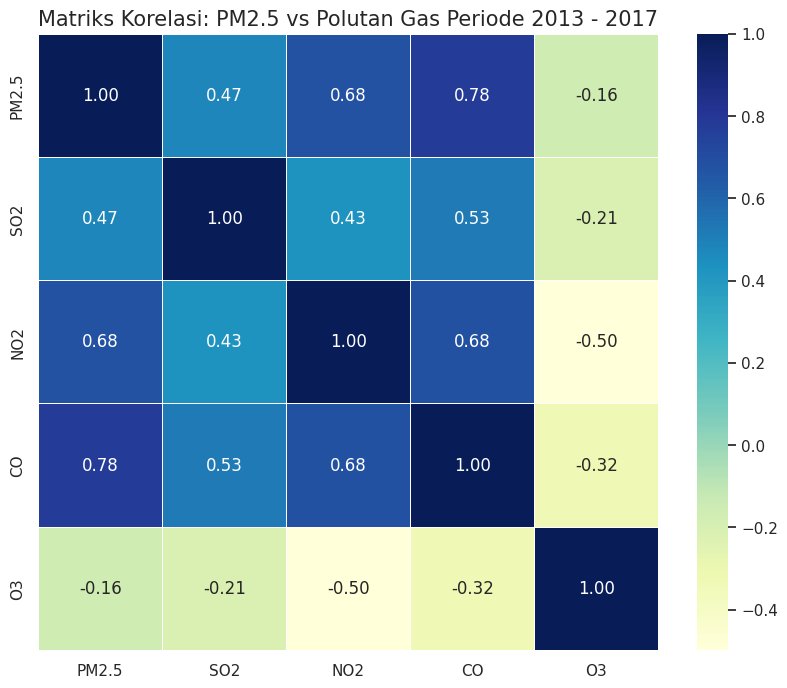

In [19]:
plt.figure(figsize=(10, 8))
corr_matrix = df[['PM2.5', 'SO2', 'NO2', 'CO', 'O3']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi: PM2.5 vs Polutan Gas Periode 2013 - 2017", fontsize=15)
plt.show()

## Rangkuman Pertanyaan 1

- Korelasi Terkuat: Polutan CO (Karbon Monoksida) memiliki nilai korelasi tertinggi dengan PM2.5 (r = 0.78), disusul oleh NO2 (r = 0.53). Ini adalah dua angka tertinggi di antara seluruh gas polutan yang dianalisis.

- Sumber Emisi: Tingginya korelasi CO dan NO2 menunjukkan bahwa PM2.5 di stasiun ini sangat dipengaruhi oleh proses pembakaran yang tidak sempurna, seperti dari knalpot kendaraan bermotor dan aktivitas industri.

- Hubungan Terbalik: O3 (Ozon) menunjukkan korelasi negatif terhadap PM2.5 (r = -0.16), karena reaksi kimia pembentukan ozon terjadi justru saat sinar matahari tinggi dan PM2.5 rendah.

### Pertanyaan 2:
Apakah terdapat perbedaan signifikan pada tingkat polusi PM2.5 antara hari kerja dan akhir pekan sepanjang tahun 2013-2017?


/tmp/ipykernel_9636/2161143072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_type', y='PM2.5', data=df, palette='Reds', estimator=np.mean)


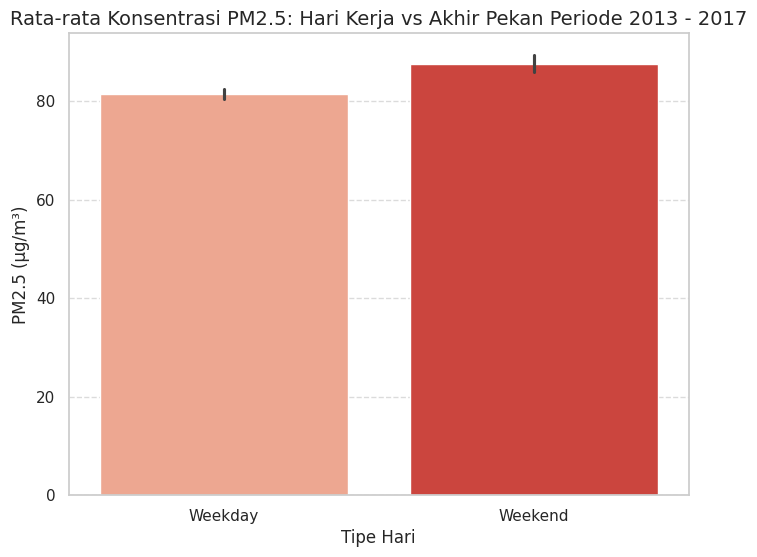

In [20]:
plt.figure(figsize=(8, 6))
sns.barplot(x='day_type', y='PM2.5', data=df, palette='Reds', estimator=np.mean)
plt.title("Rata-rata Konsentrasi PM2.5: Hari Kerja vs Akhir Pekan Periode 2013 - 2017", fontsize=14)
plt.xlabel("Tipe Hari", fontsize=12)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Rangkuman Pertanyaan 2

- Berdasarkan visualisasi, rata-rata konsentrasi PM2.5 pada Akhir Pekan (Weekend) tercatat lebih tinggi dibanding Hari Kerja (Weekday). Hal ini mengindikasikan bahwa penurunan aktivitas komuter di akhir pekan tidak serta-merta menurunkan kadar polusi udara.

- Tingginya PM2.5 di akhir pekan dapat disebabkan oleh akumulasi polutan dari hari-hari sebelumnya (background pollution) yang belum terdispersi, serta meningkatnya aktivitas rekreasi dan pembakaran (misalnya aktivitas memasak outdoor atau kegiatan komunal).

- Analisis ini menunjukkan bahwa kualitas udara di Stasiun Aotizhongxin merupakan masalah kronis yang tidak hanya dipengaruhi oleh aktivitas transportasi weekday, melainkan membutuhkan evaluasi menyeluruh sepanjang minggu.

### Pertanyaan 3:
Bagaimana pengaruh tekanan udara terhadap akumulasi polutan PM10 berdasarkan data historis tahun 2013-2017?

Kita menggunakan teknik **Binning** () untuk mengelompokkan data tekanan udara (PRES) ke dalam tiga kategori: Tekanan Rendah, Normal, dan Tinggi. Kemudian rata-rata PM10 di setiap kelompok divisualisasikan menggunakan Bar Chart untuk melihat pola penumpukan partikel berdasarkan kondisi atmosfer.

/tmp/ipykernel_9636/1214739820.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pres_summary = df.groupby('pres_group')['PM10'].mean().reset_index()
/tmp/ipykernel_9636/1214739820.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pres_group', y='PM10', data=pres_summary, palette=colors)


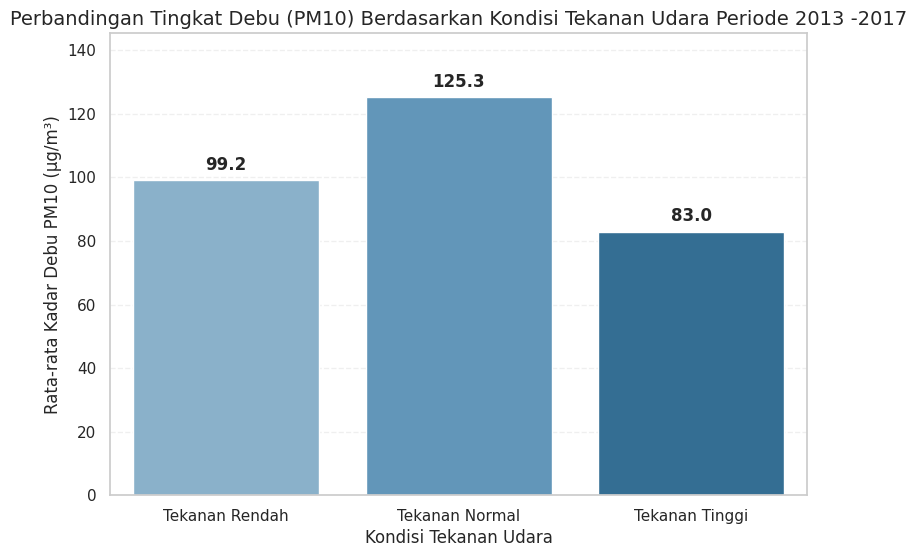

In [21]:
df['pres_group'] = pd.cut(df['PRES'], bins=3, labels=['Tekanan Rendah', 'Tekanan Normal', 'Tekanan Tinggi'])
pres_summary = df.groupby('pres_group')['PM10'].mean().reset_index()

plt.figure(figsize=(9, 6))
colors = ['#7fb3d5', '#5499c7', '#2471a3']
sns.barplot(x='pres_group', y='PM10', data=pres_summary, palette=colors)

for i, value in enumerate(pres_summary['PM10']):
    plt.text(i, value + 2, f'{value:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Perbandingan Tingkat Debu (PM10) Berdasarkan Kondisi Tekanan Udara Periode 2013 -2017", fontsize=14)
plt.xlabel("Kondisi Tekanan Udara", fontsize=12)
plt.ylabel("Rata-rata Kadar Debu PM10 (µg/m³)", fontsize=12)
plt.ylim(0, pres_summary['PM10'].max() + 20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Rangkuman Pertanyaan 3

- Berdasarkan visualisasi, kelompok **Tekanan Normal** menghasilkan rata-rata PM10 tertinggi di antara ketiga kelompok, sementara kelompok **Tekanan Rendah** mencatat PM10 terendah. Hal ini menunjukkan bahwa pada kondisi tekanan menengah ke atas, partikel debu cenderung lebih terakumulasi di permukaan.

- Tekanan udara yang stagnan atau meningkat menghalangi pergerakan massa udara secara vertikal, sehingga partikel debu (PM10) tidak dapat terdispersi dan menumpuk di dekat permukaan tanah di area stasiun pengamatan.

- Data tekanan udara berpotensi digunakan sebagai indikator peringatan dini (Early Warning System) untuk memantau hari-hari dengan risiko penumpukan polusi tinggi, terutama bagi kelompok rentan seperti anak-anak dan lansia.

# Kesimpulan

Berdasarkan seluruh proses analisis data yang telah dilakukan, dapat disimpulkan beberapa poin utama:

**Pertanyaan 1 — Korelasi Polutan Gas terhadap PM2.5:**
- Polutan CO memiliki korelasi tertinggi dengan PM2.5 (r = 0.78), disusul NO2 (r = 0.53), mengonfirmasi bahwa sumber pembakaran adalah kontributor utama partikel halus di Stasiun Aotizhongxin.
- O3 menunjukkan korelasi negatif (r = -0.16), karena pembentukannya terjadi pada kondisi berbeda dengan PM2.5.

**Pertanyaan 2 — Weekday vs Weekend:**
- PM2.5 pada akhir pekan tercatat sedikit lebih tinggi dibanding hari kerja, menunjukkan bahwa polusi udara adalah masalah kronis yang tidak hilang hanya dengan berkurangnya aktivitas komuter.

**Pertanyaan 3 — Tekanan Udara vs PM10:**
- Kelompok tekanan Normal mencatat PM10 rata-rata tertinggi. Tekanan udara yang stagnan menghambat dispersi partikel sehingga polutan terakumulasi di dekat permukaan.

---

## Rekomendasi Action Item

1. **Pengetatan emisi kendaraan & industri**: Karena CO dan NO2 adalah prediktor terkuat PM2.5, pemerintah perlu memperketat standar emisi kendaraan bermotor dan cerobong industri di sekitar stasiun Aotizhongxin, khususnya pada jam-jam sibuk.

2. **Sistem peringatan dini berbasis tekanan udara**: Gunakan data tekanan udara harian sebagai trigger peringatan otomatis. Ketika tekanan udara memasuki kategori Normal-Tinggi selama 2+ hari berturut-turut, kirimkan notifikasi kepada kelompok rentan (anak-anak, lansia, penderita asma) untuk membatasi aktivitas di luar ruangan.

3. **Evaluasi kebijakan pembatasan kendaraan**: Karena PM2.5 tidak turun signifikan di akhir pekan, kebijakan ganjil-genap atau car-free day yang hanya diterapkan di hari kerja perlu dievaluasi. Perlu dikaji apakah perluasan ke akhir pekan memberikan dampak yang lebih signifikan.

## Menyimpan Dataset Bersih untuk Dashboard

Dataset yang sudah dibersihkan dan diperkaya disimpan ke folder `dashboard/` agar aplikasi Streamlit memakai data yang konsisten dengan notebook analisis.

In [22]:
if not os.path.exists('dashboard'):
    os.makedirs('dashboard')
df.to_csv("dashboard/all_data.csv", index=False)
print("Berhasil! Dataset siap digunakan untuk dashboard Streamlit.")

Berhasil! Dataset siap digunakan untuk dashboard Streamlit.
